# Profiler Trace Summary

Summaries of Torch profiler traces under `TransformerLens/benchmark/results/profile_traces`.


In [1]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


# Hidden_only
 

In [ ]:
# Profiler trace root (relative to this notebook)
TRACE_ROOT = (
    Path.cwd().parent.parent
    / "TransformerLens"
    / "results"
    / "hidden_only_decode"
)

BASELINE_ORDER = [
    "huggingface",
    "huggingface_api",
    "huggingface_hook",
    "huggingface_hook_cpu",
    "transformer_lens",
    "transformer_lens_cache",
]

if not TRACE_ROOT.exists():
    raise FileNotFoundError(f"Trace root not found: {TRACE_ROOT}")


FileNotFoundError: Trace root not found: /home/nengneng/AIPrometheus/TransformerLens/results/hidden_only_decode

In [ ]:
from collections import defaultdict
from typing import Dict, Iterable, List, Optional, Tuple

SECONDS_PER_MICROSECOND = 1_000_000

CPU_CATEGORIES = {"cpu_op"}
GPU_CATEGORIES = {"kernel"}
MEMORY_CATEGORIES = {"gpu_memcpy"}
MEMORY_NAME_KEYWORDS = ("memcpy", "memset", "memory", "cudamalloc", "cudafree")

CPU_CATEGORY_RULES = [
    ("GEMM/Matmul (aten)", ["mm", "bmm", "matmul", "addmm", "gemm", "linear", "einsum", "mv", "matvec"]),
    ("Attention/Softmax (aten)", ["softmax", "attention", "scaled_dot_product", "multi_head_attention", "flash_attn"]),
    ("LayerNorm (aten)", ["layer_norm", "native_layer_norm", "rms_norm", "layernorm", "rmsnorm"]),
    ("Index/Shape (aten)", ["view", "reshape", "slice", "index", "select", "narrow", "gather", "scatter", "squeeze", "unsqueeze", "take"]),
    ("Layout/Permute (aten)", ["permute", "transpose", "contiguous", "rearrange"]),
    ("Copy/Clone (aten)", ["clone", "detach", "copy", "cat", "stack", "roll", "concatenate", "tile", "repeat"]),
    ("Tensor Create (aten)", ["empty", "zeros", "ones", "full", "rand", "randn", "eye", "new_zeros", "new_empty"]),
    ("Pointwise (aten)", [
        "add", "sub", "mul", "div", "where", "gelu", "tanh", "sigmoid", "relu", "hardtanh",
        "pow", "sqrt", "log", "exp", "sin", "cos", "erf", "clamp", "floor", "ceil", "round",
        "leaky_relu", "silu", "elu", "dropout"
    ]),
]

CATEGORY_COLORS: Dict[str, str] = {
    "CUDA memcpy/memset": "#6baed6",
    "CUDA malloc/free": "#9ecae1",
    "CUDA runtime (other)": "#c6dbef",
    "GPU kernel (other)": "#08519c",
    "GEMM/Matmul (aten)": "#d62728",
    "Attention/Softmax (aten)": "#ff9896",
    "LayerNorm (aten)": "#9467bd",
    "Index/Shape (aten)": "#8c564b",
    "Layout/Permute (aten)": "#e377c2",
    "Copy/Clone (aten)": "#7f7f7f",
    "Tensor Create (aten)": "#bcbd22",
    "Pointwise (aten)": "#17becf",
    "aten::other": "#bdbdbd",
    "Annotations": "#969696",
    "other": "#636363",
}

CPU_CATEGORY_ORDER = [rule[0] for rule in CPU_CATEGORY_RULES] + ["aten::other"]
GPU_CATEGORY_ORDER = [
    "CUDA memcpy/memset",
    "CUDA malloc/free",
    "CUDA runtime (other)",
    "GPU kernel (other)",
]
EXTRA_CATEGORY_ORDER = ["Annotations", "other"]
CATEGORY_ORDER = GPU_CATEGORY_ORDER + CPU_CATEGORY_ORDER + EXTRA_CATEGORY_ORDER


def interval_union_duration(intervals: Iterable[Tuple[float, float]]) -> float:
    sorted_intervals = sorted(intervals)
    if not sorted_intervals:
        return 0.0
    total = 0.0
    current_start, current_end = sorted_intervals[0]
    for start, end in sorted_intervals[1:]:
        if start <= current_end:
            current_end = max(current_end, end)
        else:
            total += current_end - current_start
            current_start, current_end = start, end
    total += current_end - current_start
    return total


def classify_cpu_event(name: str) -> str:
    if not name.startswith("aten::"):
        return "aten::other"
    lowered = name[6:].lower()
    for category, keywords in CPU_CATEGORY_RULES:
        if any(keyword in lowered for keyword in keywords):
            return category
    return "aten::other"


def classify_cuda_runtime(name: str) -> str:
    lowered = name.lower()
    if "memcpy" in lowered or "memset" in lowered:
        return "CUDA memcpy/memset"
    if "malloc" in lowered or "free" in lowered:
        return "CUDA malloc/free"
    return "CUDA runtime (other)"


def get_color(category: str) -> str:
    return CATEGORY_COLORS.get(category, "#333333")


def collect_intervals(events: List[dict], predicate) -> List[Tuple[float, float]]:
    intervals = []
    for event in events:
        if event.get("ph") != "X":
            continue
        if not predicate(event):
            continue
        start = event.get("ts")
        duration = event.get("dur")
        if start is None or duration is None:
            continue
        intervals.append((start, start + duration))
    return intervals


def accumulate_durations(events: List[dict]) -> Dict[str, float]:
    cpu_intervals = collect_intervals(
        events,
        lambda evt: (evt.get("cat") or "").lower() in CPU_CATEGORIES,
    )
    gpu_intervals = collect_intervals(
        events,
        lambda evt: (evt.get("cat") or "").lower() in GPU_CATEGORIES,
    )
    memory_intervals = collect_intervals(
        events,
        lambda evt: (
            (evt.get("cat") or "").lower() in MEMORY_CATEGORIES
            or any(keyword in (evt.get("name") or "").lower() for keyword in MEMORY_NAME_KEYWORDS)
        ),
    )

    return {
        "cpu_seconds": interval_union_duration(cpu_intervals) / SECONDS_PER_MICROSECOND,
        "gpu_seconds": interval_union_duration(gpu_intervals) / SECONDS_PER_MICROSECOND,
        "memory_seconds": interval_union_duration(memory_intervals) / SECONDS_PER_MICROSECOND,
    }


def collect_breakdown(events: List[dict]) -> Dict[str, float]:
    totals: Dict[str, float] = defaultdict(float)
    for event in events:
        if event.get("ph") != "X":
            continue
        duration = event.get("dur", 0.0) / SECONDS_PER_MICROSECOND
        category = event.get("cat") or ""
        name = event.get("name") or ""

        if category == "cpu_op":
            totals[classify_cpu_event(name)] += duration
        elif category == "cuda_runtime":
            totals[classify_cuda_runtime(name)] += duration
        elif category == "kernel":
            totals["GPU kernel (other)"] += duration
        elif category in {"user_annotation", "gpu_user_annotation", "Trace"}:
            totals["Annotations"] += duration
        else:
            totals["other"] += duration
    return totals


def parse_trace(trace_path: Path) -> Optional[Tuple[Dict[str, object], Dict[str, float]]]:
    with trace_path.open() as fh:
        trace = json.load(fh)

    events = trace.get("traceEvents", [])
    cpu_span = next((evt for evt in events if evt.get("cat") == "user_annotation"), None)
    if cpu_span is None:
        return None

    baseline = cpu_span.get("name") or trace_path.parent.name
    totals = accumulate_durations(events)
    breakdown = collect_breakdown(events)

    summary = {
        "baseline": baseline,
        "trace_path": trace_path.relative_to(TRACE_ROOT).as_posix(),
        "total_seconds": cpu_span.get("dur", 0.0) / SECONDS_PER_MICROSECOND,
        **totals,
    }
    return summary, breakdown


def format_seconds(value: float) -> str:
    if value >= 1:
        return f"{value:.2f} s"
    if value >= 0.01:
        return f"{value:.3f} s"
    if value >= 0.001:
        return f"{value * 1_000:.2f} ms"
    if value >= 0.000001:
        return f"{value * 1_000_000:.1f} µs"
    return f"{value * 1_000_000:.2f} µs"


def format_signed_seconds(value: float) -> str:
    prefix = "+" if value >= 0 else "-"
    return prefix + format_seconds(abs(value))


In [ ]:
summary_records = []
breakdown_records = []

for trace_path in sorted(TRACE_ROOT.rglob("*.json")):
    parsed = parse_trace(trace_path)
    if not parsed:
        continue
    summary, breakdown = parsed
    summary_records.append(summary)
    for category, seconds in breakdown.items():
        breakdown_records.append({
            "baseline": summary["baseline"],
            "trace_path": summary["trace_path"],
            "category": category,
            "seconds": seconds,
        })

runs_df = pd.DataFrame(summary_records)
breakdown_df = pd.DataFrame(breakdown_records)
runs_df


,baseline,trace_path,total_seconds,cpu_seconds,gpu_seconds,memory_seconds
0,huggingface,huggingface/FROOT-Lab_2160174.1759194260547827...,0.088952,0.022817,0.072689,0.014443
1,huggingface,huggingface/FROOT-Lab_2161304.1759194288601478...,0.088968,0.023738,0.072712,0.015057
2,huggingface,huggingface/FROOT-Lab_2162619.1759194320382539...,0.191951,0.024877,0.175634,0.016371
3,huggingface,huggingface/FROOT-Lab_2165955.1759194400708836...,0.087951,0.021664,0.072753,0.013223
4,huggingface_api,huggingface_api/FROOT-Lab_2160174.175919426067...,0.087307,0.024036,0.070915,0.014150
5,huggingface_api,huggingface_api/FROOT-Lab_2161304.175919428873...,0.087329,0.027223,0.070932,0.017073
6,huggingface_api,huggingface_api/FROOT-Lab_2162619.175919432062...,0.189031,0.029181,0.172553,0.019094
7,huggingface_api,huggingface_api/FROOT-Lab_2165955.175919440083...,0.086269,0.023918,0.071084,0.013789
8,huggingface_hook,huggingface_hook/FROOT-Lab_2160174.17591942609...,0.087887,0.028156,0.071176,0.018107
9,huggingface_hook,huggingface_hook/FROOT-Lab_2161304.17591942890...,0.092522,0.047468,0.073174,0.035887


In [ ]:
if runs_df.empty:
    raise ValueError("No trace data found. Check TRACE_ROOT.")

order = pd.CategoricalDtype(categories=BASELINE_ORDER, ordered=True)
runs_df["baseline"] = runs_df["baseline"].astype(order)
breakdown_df["baseline"] = breakdown_df["baseline"].astype(order)

summary_df = (
    runs_df
    .groupby("baseline")
    .agg(
        runs=("trace_path", "count"),
        mean_total_s=("total_seconds", "mean"),
        std_total_s=("total_seconds", "std"),
        mean_cpu_s=("cpu_seconds", "mean"),
        mean_gpu_s=("gpu_seconds", "mean"),
        mean_memory_s=("memory_seconds", "mean"),
    )
    .reset_index()
    .sort_values("baseline")
)
summary_df


/tmp/ipykernel_1664459/3174425702.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("baseline")


,baseline,runs,mean_total_s,std_total_s,mean_cpu_s,mean_gpu_s,mean_memory_s
0,huggingface,4,0.114456,0.051666,0.023274,0.098447,0.014773
1,huggingface_api,4,0.112484,0.051034,0.026090,0.096371,0.016027
2,huggingface_hook,4,0.114064,0.050562,0.035133,0.097063,0.024559
3,huggingface_hook_cpu,4,1.604581,0.731144,1.482584,0.095805,1.468434
4,transformer_lens,4,0.171828,0.105730,0.014502,0.169270,0.006345
5,transformer_lens_cache,4,0.198646,0.107012,0.114662,0.175582,0.100157


/tmp/ipykernel_1664459/3250747413.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(summary_df["baseline"], rotation=35, ha="right")


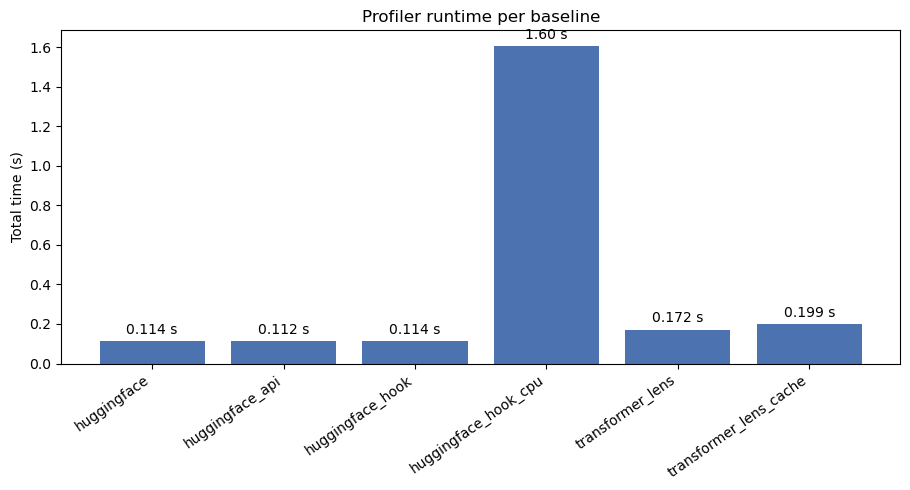

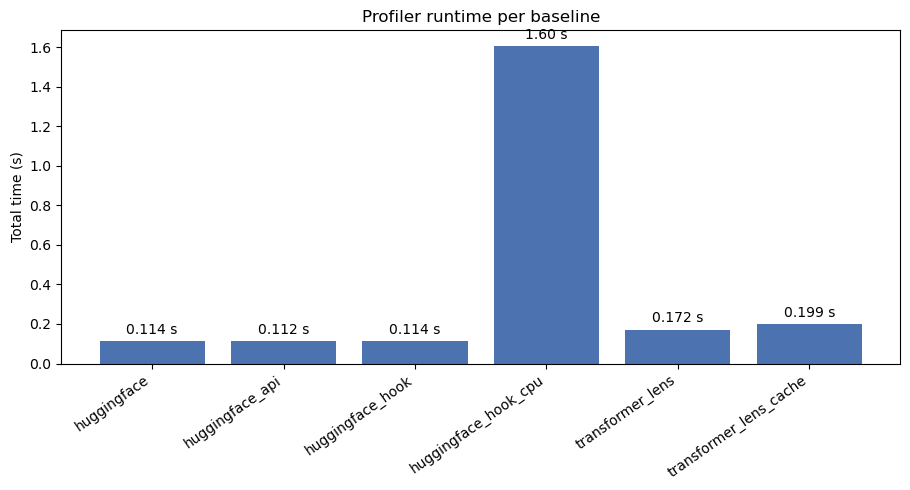

In [ ]:
# Vertical bar chart for total runtime per baseline
fig, ax = plt.subplots(figsize=(1.2 * len(summary_df) + 2, 5))

bars = ax.bar(summary_df["baseline"], summary_df["mean_total_s"], color="#4c72b0")
ax.set_ylabel("Total time (s)")
ax.set_title("Profiler runtime per baseline")
ax.set_xticklabels(summary_df["baseline"], rotation=35, ha="right")

ax.bar_label(bars, labels=[format_seconds(v) for v in summary_df["mean_total_s"]], padding=3)
plt.tight_layout()
fig


/tmp/ipykernel_1664459/1150996947.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(summary_df["baseline"], rotation=35, ha="right")
/tmp/ipykernel_1664459/1150996947.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(summary_df["baseline"], rotation=35, ha="right")
/tmp/ipykernel_1664459/1150996947.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(summary_df["baseline"], rotation=35, ha="right")


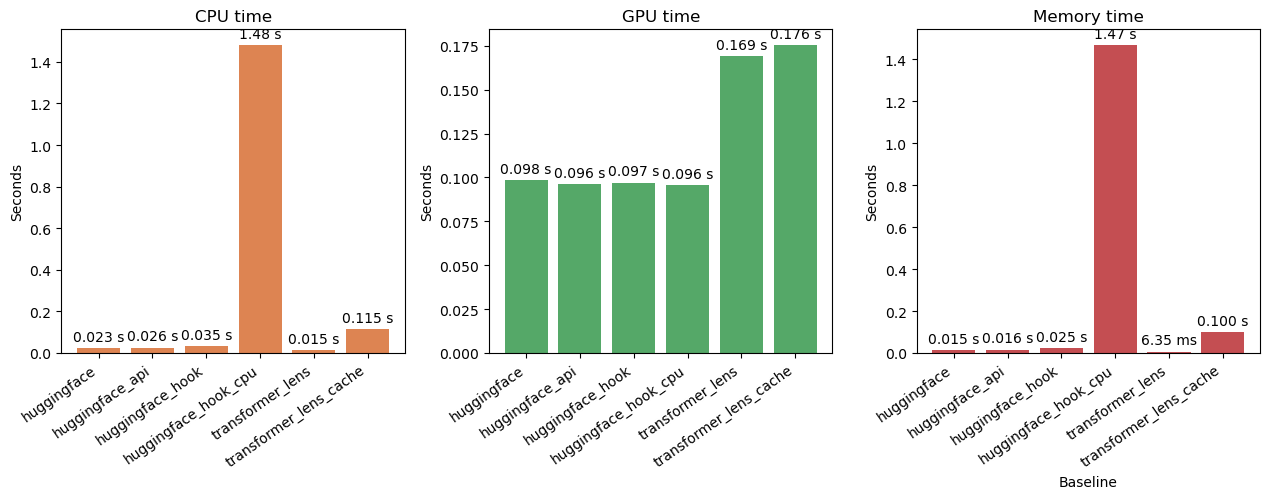

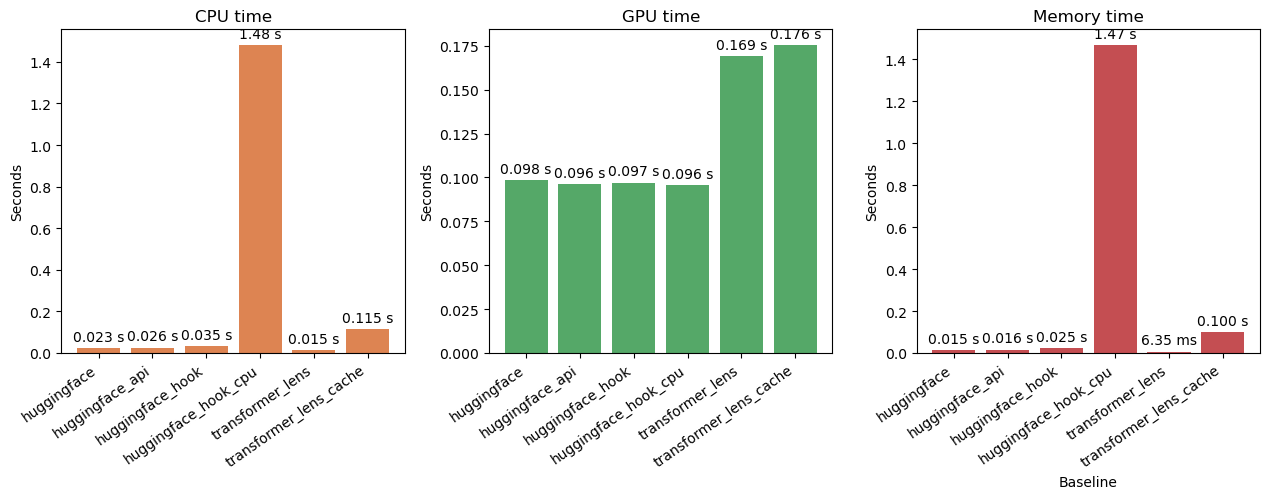

In [ ]:
# CPU / GPU / Memory time comparisons (vertical bars)
metrics = [
    ("mean_cpu_s", "CPU time", "#dd8452"),
    ("mean_gpu_s", "GPU time", "#55a868"),
    ("mean_memory_s", "Memory time", "#c44e52"),
]

fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    sharex=True,
    figsize=(1.8 * len(summary_df) + 2, 1.7 * len(metrics)),
)

if len(metrics) == 1:
    axes = [axes]

for ax, (column, title, color) in zip(axes, metrics):
    bars = ax.bar(summary_df["baseline"], summary_df[column], color=color)
    ax.set_ylabel("Seconds")
    ax.set_title(title)
    ax.bar_label(bars, labels=[format_seconds(v) for v in summary_df[column]], padding=3)
    ax.set_xticklabels(summary_df["baseline"], rotation=35, ha="right")

axes[-1].set_xlabel("Baseline")
plt.tight_layout()
fig


## Detailed operator/runtime breakdown

Aggregate averaged durations by category for the focused baselines.


In [ ]:
breakdown_mean_df = (
    breakdown_df
    .groupby(["baseline", "category"])
    .agg(mean_seconds=("seconds", "mean"))
    .reset_index()
)
focus_breakdown = (
    breakdown_mean_df
    .pivot(index="baseline", columns="category", values="mean_seconds")
    .fillna(0.0)
    .reindex(index=focus_order)
)
focus_breakdown = focus_breakdown.reindex(columns=CATEGORY_ORDER, fill_value=0.0)
focus_breakdown


/tmp/ipykernel_1664459/1140002705.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["baseline", "category"])


category,CUDA memcpy/memset,CUDA malloc/free,CUDA runtime (other),GPU kernel (other),GEMM/Matmul (aten),Attention/Softmax (aten),LayerNorm (aten),Index/Shape (aten),Layout/Permute (aten),Copy/Clone (aten),Tensor Create (aten),Pointwise (aten),aten::other,Annotations,other
baseline,,,,,,,,,,,,,,,
transformer_lens_cache,0.000003,0.096931,0.068172,0.175582,0.056731,0.000292,0.000000,0.012626,0.000398,0.019611,0.059597,0.039381,0.036501,0.588205,0.001595
transformer_lens,0.000003,0.000000,0.152380,0.169270,0.005759,0.000275,0.000000,0.002981,0.000482,0.005805,0.001690,0.004584,0.004289,0.513897,0.001598
huggingface_hook,0.000014,0.024543,0.074446,0.097063,0.013250,0.000241,0.003207,0.009687,0.001165,0.004807,0.007978,0.018885,0.013725,0.339011,0.001278
huggingface_api,0.000014,0.016010,0.082075,0.096371,0.011325,0.000246,0.002832,0.018087,0.000737,0.004111,0.007246,0.010857,0.016479,0.334135,0.001576


/tmp/ipykernel_1664459/1560463280.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(focus_breakdown.index, rotation=20, ha="right")


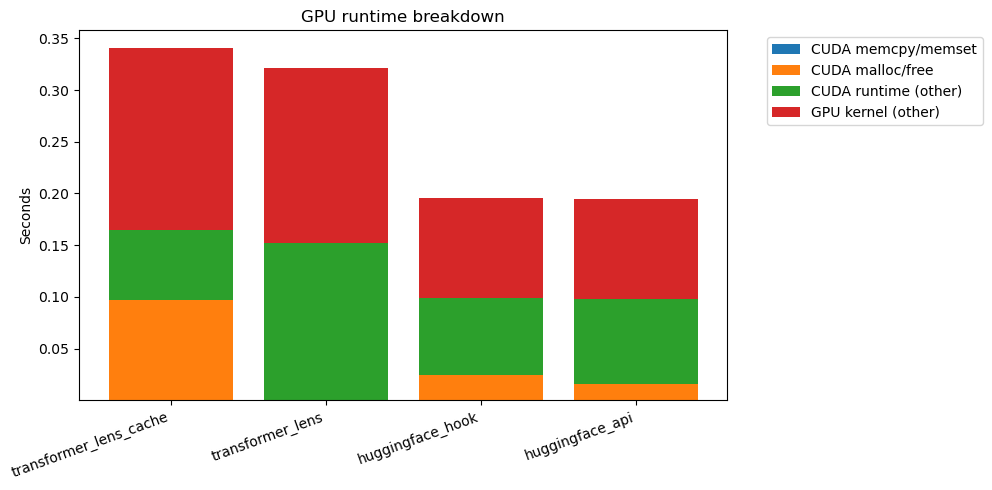

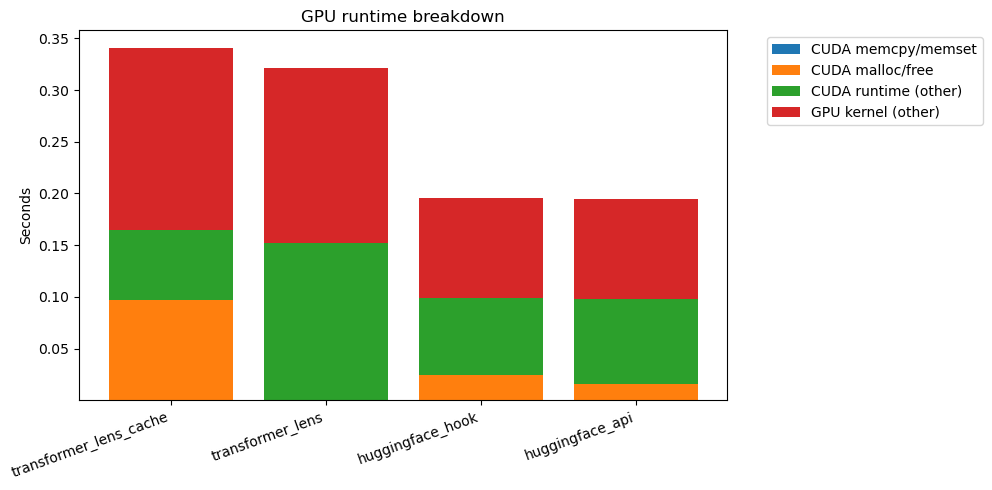

In [ ]:
# Stacked bar chart: GPU-related categories (high-contrast colors)
gpu_categories = [cat for cat in GPU_CATEGORY_ORDER if cat in focus_breakdown.columns]

# Define a high-contrast color palette
high_contrast_colors = [
    "#1f77b4",  # blue
    "#ff7f0e",  # orange
    "#2ca02c",  # green
    "#d62728",  # red
    "#9467bd",  # purple
    "#8c564b",  # brown
    "#e377c2",  # pink
    "#7f7f7f",  # gray
    "#bcbd22",  # yellow-green
    "#17becf",  # cyan
    "#000000",  # black
    "#FFD700",  # gold
    "#00CED1",  # dark turquoise
    "#FF1493",  # deep pink
    "#228B22",  # forest green
    "#FF4500",  # orange red
]

# Assign colors to categories, cycling if needed
category_colors = {cat: high_contrast_colors[i % len(high_contrast_colors)] for i, cat in enumerate(gpu_categories)}

fig, ax = plt.subplots(figsize=(10, 5))
bottom = pd.Series([0.0] * len(focus_breakdown), index=focus_breakdown.index)
for category in gpu_categories:
    values = focus_breakdown[category]
    if values.sum() == 0:
        continue
    bars = ax.bar(
        focus_breakdown.index,
        values,
        bottom=bottom,
        color=category_colors[category],
        label=category
    )
    bottom += values
ax.set_ylabel("Seconds")
ax.set_title("GPU runtime breakdown")
ax.set_xticklabels(focus_breakdown.index, rotation=20, ha="right")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
fig


/tmp/ipykernel_1664459/677368869.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(focus_breakdown.index, rotation=20, ha="right")


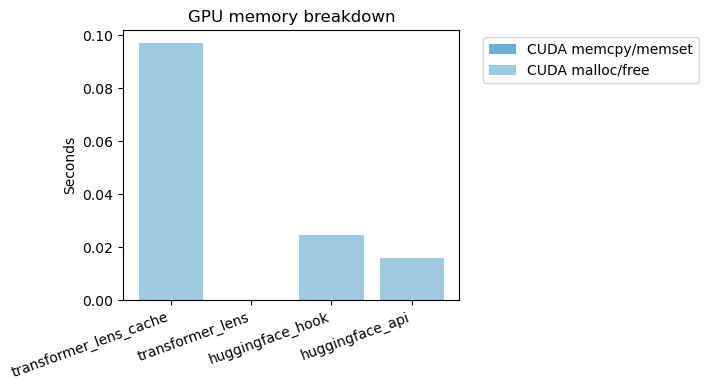

In [ ]:
# Stacked bar chart: Memory-related categories
memory_categories = [cat for cat in gpu_categories if 'mem' in cat.lower() or 'malloc' in cat.lower() or 'free' in cat.lower()]
if memory_categories:
    fig, ax = plt.subplots(figsize=(7, 4))
    bottom = pd.Series([0.0] * len(focus_breakdown), index=focus_breakdown.index)
    for category in memory_categories:
        values = focus_breakdown[category]
        if values.sum() == 0:
            continue
        bars = ax.bar(
            focus_breakdown.index,
            values,
            bottom=bottom,
            color=get_color(category),
            label=category,
        )
        bottom += values
    ax.set_ylabel("Seconds")
    ax.set_title("GPU memory breakdown")
    ax.set_xticklabels(focus_breakdown.index, rotation=20, ha="right")
    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    fig


/tmp/ipykernel_1664459/966767413.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(focus_breakdown.index, rotation=20, ha="right")


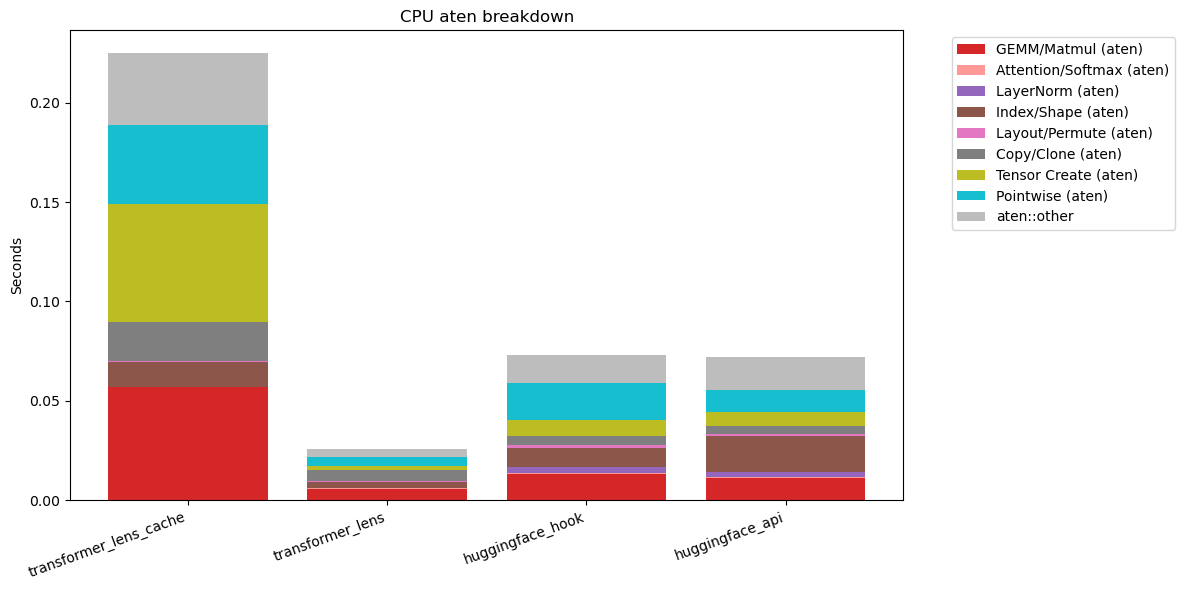

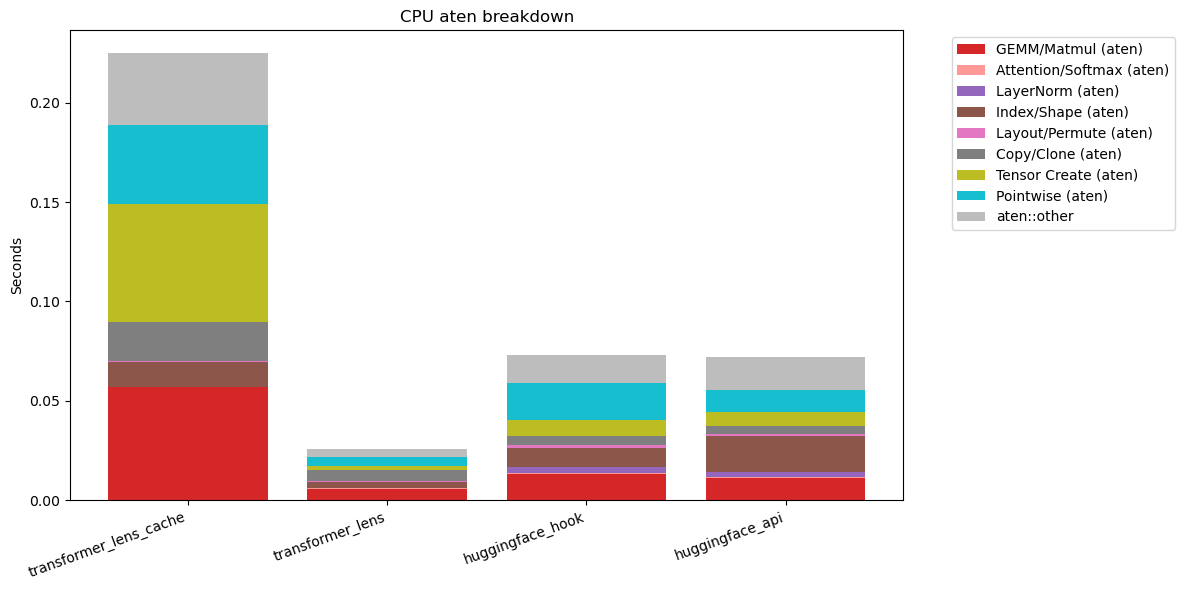

In [ ]:
# Stacked bar chart: CPU aten categories
cpu_categories = [cat for cat in CPU_CATEGORY_ORDER if cat in focus_breakdown.columns]
fig, ax = plt.subplots(figsize=(12, 6))
bottom = pd.Series([0.0] * len(focus_breakdown), index=focus_breakdown.index)
for category in cpu_categories:
    values = focus_breakdown[category]
    if values.sum() == 0:
        continue
    bars = ax.bar(focus_breakdown.index, values, bottom=bottom, color=get_color(category), label=category)
    bottom += values
ax.set_ylabel("Seconds")
ax.set_title("CPU aten breakdown")
ax.set_xticklabels(focus_breakdown.index, rotation=20, ha="right")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
fig
fig


# Hidden_attention

 

In [ ]:
# Profiler trace root (relative to this notebook)
TRACE_ROOT = (
    Path.cwd().parent.parent
    / "TransformerLens"
    / "results"
    / "hidden_attention_decode"
)

BASELINE_ORDER = [
    "huggingface",
    "huggingface_api",
    "huggingface_hook",
    "huggingface_hook_cpu",
    "transformer_lens",
    "transformer_lens_cache",
]

if not TRACE_ROOT.exists():
    raise FileNotFoundError(f"Trace root not found: {TRACE_ROOT}")


In [ ]:
from collections import defaultdict
from typing import Dict, Iterable, List, Optional, Tuple

SECONDS_PER_MICROSECOND = 1_000_000

CPU_CATEGORIES = {"cpu_op"}
GPU_CATEGORIES = {"kernel"}
MEMORY_CATEGORIES = {"gpu_memcpy"}
MEMORY_NAME_KEYWORDS = ("memcpy", "memset", "memory", "cudamalloc", "cudafree")

CPU_CATEGORY_RULES = [
    ("GEMM/Matmul (aten)", ["mm", "bmm", "matmul", "addmm", "gemm", "linear", "einsum", "mv", "matvec"]),
    ("Attention/Softmax (aten)", ["softmax", "attention", "scaled_dot_product", "multi_head_attention", "flash_attn"]),
    ("LayerNorm (aten)", ["layer_norm", "native_layer_norm", "rms_norm", "layernorm", "rmsnorm"]),
    ("Index/Shape (aten)", ["view", "reshape", "slice", "index", "select", "narrow", "gather", "scatter", "squeeze", "unsqueeze", "take"]),
    ("Layout/Permute (aten)", ["permute", "transpose", "contiguous", "rearrange"]),
    ("Copy/Clone (aten)", ["clone", "detach", "copy", "cat", "stack", "roll", "concatenate", "tile", "repeat"]),
    ("Tensor Create (aten)", ["empty", "zeros", "ones", "full", "rand", "randn", "eye", "new_zeros", "new_empty"]),
    ("Pointwise (aten)", [
        "add", "sub", "mul", "div", "where", "gelu", "tanh", "sigmoid", "relu", "hardtanh",
        "pow", "sqrt", "log", "exp", "sin", "cos", "erf", "clamp", "floor", "ceil", "round",
        "leaky_relu", "silu", "elu", "dropout"
    ]),
]

CATEGORY_COLORS: Dict[str, str] = {
    "CUDA memcpy/memset": "#6baed6",
    "CUDA malloc/free": "#9ecae1",
    "CUDA runtime (other)": "#c6dbef",
    "GPU kernel (other)": "#08519c",
    "GEMM/Matmul (aten)": "#d62728",
    "Attention/Softmax (aten)": "#ff9896",
    "LayerNorm (aten)": "#9467bd",
    "Index/Shape (aten)": "#8c564b",
    "Layout/Permute (aten)": "#e377c2",
    "Copy/Clone (aten)": "#7f7f7f",
    "Tensor Create (aten)": "#bcbd22",
    "Pointwise (aten)": "#17becf",
    "aten::other": "#bdbdbd",
    "Annotations": "#969696",
    "other": "#636363",
}

CPU_CATEGORY_ORDER = [rule[0] for rule in CPU_CATEGORY_RULES] + ["aten::other"]
GPU_CATEGORY_ORDER = [
    "CUDA memcpy/memset",
    "CUDA malloc/free",
    "CUDA runtime (other)",
    "GPU kernel (other)",
]
EXTRA_CATEGORY_ORDER = ["Annotations", "other"]
CATEGORY_ORDER = GPU_CATEGORY_ORDER + CPU_CATEGORY_ORDER + EXTRA_CATEGORY_ORDER


def interval_union_duration(intervals: Iterable[Tuple[float, float]]) -> float:
    sorted_intervals = sorted(intervals)
    if not sorted_intervals:
        return 0.0
    total = 0.0
    current_start, current_end = sorted_intervals[0]
    for start, end in sorted_intervals[1:]:
        if start <= current_end:
            current_end = max(current_end, end)
        else:
            total += current_end - current_start
            current_start, current_end = start, end
    total += current_end - current_start
    return total


def classify_cpu_event(name: str) -> str:
    if not name.startswith("aten::"):
        return "aten::other"
    lowered = name[6:].lower()
    for category, keywords in CPU_CATEGORY_RULES:
        if any(keyword in lowered for keyword in keywords):
            return category
    return "aten::other"


def classify_cuda_runtime(name: str) -> str:
    lowered = name.lower()
    if "memcpy" in lowered or "memset" in lowered:
        return "CUDA memcpy/memset"
    if "malloc" in lowered or "free" in lowered:
        return "CUDA malloc/free"
    return "CUDA runtime (other)"


def get_color(category: str) -> str:
    return CATEGORY_COLORS.get(category, "#333333")


def collect_intervals(events: List[dict], predicate) -> List[Tuple[float, float]]:
    intervals = []
    for event in events:
        if event.get("ph") != "X":
            continue
        if not predicate(event):
            continue
        start = event.get("ts")
        duration = event.get("dur")
        if start is None or duration is None:
            continue
        intervals.append((start, start + duration))
    return intervals


def accumulate_durations(events: List[dict]) -> Dict[str, float]:
    cpu_intervals = collect_intervals(
        events,
        lambda evt: (evt.get("cat") or "").lower() in CPU_CATEGORIES,
    )
    gpu_intervals = collect_intervals(
        events,
        lambda evt: (evt.get("cat") or "").lower() in GPU_CATEGORIES,
    )
    memory_intervals = collect_intervals(
        events,
        lambda evt: (
            (evt.get("cat") or "").lower() in MEMORY_CATEGORIES
            or any(keyword in (evt.get("name") or "").lower() for keyword in MEMORY_NAME_KEYWORDS)
        ),
    )

    return {
        "cpu_seconds": interval_union_duration(cpu_intervals) / SECONDS_PER_MICROSECOND,
        "gpu_seconds": interval_union_duration(gpu_intervals) / SECONDS_PER_MICROSECOND,
        "memory_seconds": interval_union_duration(memory_intervals) / SECONDS_PER_MICROSECOND,
    }


def collect_breakdown(events: List[dict]) -> Dict[str, float]:
    totals: Dict[str, float] = defaultdict(float)
    for event in events:
        if event.get("ph") != "X":
            continue
        duration = event.get("dur", 0.0) / SECONDS_PER_MICROSECOND
        category = event.get("cat") or ""
        name = event.get("name") or ""

        if category == "cpu_op":
            totals[classify_cpu_event(name)] += duration
        elif category == "cuda_runtime":
            totals[classify_cuda_runtime(name)] += duration
        elif category == "kernel":
            totals["GPU kernel (other)"] += duration
        elif category in {"user_annotation", "gpu_user_annotation", "Trace"}:
            totals["Annotations"] += duration
        else:
            totals["other"] += duration
    return totals


def parse_trace(trace_path: Path) -> Optional[Tuple[Dict[str, object], Dict[str, float]]]:
    with trace_path.open() as fh:
        trace = json.load(fh)

    events = trace.get("traceEvents", [])
    cpu_span = next((evt for evt in events if evt.get("cat") == "user_annotation"), None)
    if cpu_span is None:
        return None

    baseline = cpu_span.get("name") or trace_path.parent.name
    totals = accumulate_durations(events)
    breakdown = collect_breakdown(events)

    summary = {
        "baseline": baseline,
        "trace_path": trace_path.relative_to(TRACE_ROOT).as_posix(),
        "total_seconds": cpu_span.get("dur", 0.0) / SECONDS_PER_MICROSECOND,
        **totals,
    }
    return summary, breakdown


def format_seconds(value: float) -> str:
    if value >= 1:
        return f"{value:.2f} s"
    if value >= 0.01:
        return f"{value:.3f} s"
    if value >= 0.001:
        return f"{value * 1_000:.2f} ms"
    if value >= 0.000001:
        return f"{value * 1_000_000:.1f} µs"
    return f"{value * 1_000_000:.2f} µs"


def format_signed_seconds(value: float) -> str:
    prefix = "+" if value >= 0 else "-"
    return prefix + format_seconds(abs(value))


In [ ]:
summary_records = []
breakdown_records = []

for trace_path in sorted(TRACE_ROOT.rglob("*.json")):
    parsed = parse_trace(trace_path)
    if not parsed:
        continue
    summary, breakdown = parsed
    summary_records.append(summary)
    for category, seconds in breakdown.items():
        breakdown_records.append({
            "baseline": summary["baseline"],
            "trace_path": summary["trace_path"],
            "category": category,
            "seconds": seconds,
        })

runs_df = pd.DataFrame(summary_records)
breakdown_df = pd.DataFrame(breakdown_records)
runs_df


,baseline,trace_path,total_seconds,cpu_seconds,gpu_seconds,memory_seconds
0,huggingface,huggingface/FROOT-Lab_2164716.1759194372204161...,0.088976,0.023714,0.072789,0.015028
1,huggingface_api,huggingface_api/FROOT-Lab_2164716.175919437233...,0.087306,0.027011,0.070952,0.016682
2,huggingface_hook,huggingface_hook/FROOT-Lab_2164716.17591943726...,0.092469,0.047739,0.073265,0.035658
3,huggingface_hook_cpu,huggingface_hook_cpu/FROOT-Lab_2164716.1759194...,2.103230,1.995215,0.073149,1.978834
4,transformer_lens,transformer_lens/FROOT-Lab_2164716.17591943716...,0.119055,0.014510,0.116532,0.004604
5,transformer_lens_cache,transformer_lens_cache/FROOT-Lab_2164716.17591...,0.156516,0.122167,0.121120,0.103685


In [ ]:
if runs_df.empty:
    raise ValueError("No trace data found. Check TRACE_ROOT.")

order = pd.CategoricalDtype(categories=BASELINE_ORDER, ordered=True)
runs_df["baseline"] = runs_df["baseline"].astype(order)
breakdown_df["baseline"] = breakdown_df["baseline"].astype(order)

summary_df = (
    runs_df
    .groupby("baseline")
    .agg(
        runs=("trace_path", "count"),
        mean_total_s=("total_seconds", "mean"),
        std_total_s=("total_seconds", "std"),
        mean_cpu_s=("cpu_seconds", "mean"),
        mean_gpu_s=("gpu_seconds", "mean"),
        mean_memory_s=("memory_seconds", "mean"),
    )
    .reset_index()
    .sort_values("baseline")
)
summary_df


/tmp/ipykernel_1664459/3174425702.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("baseline")


,baseline,runs,mean_total_s,std_total_s,mean_cpu_s,mean_gpu_s,mean_memory_s
0,huggingface,1,0.088976,NaN,0.023714,0.072789,0.015028
1,huggingface_api,1,0.087306,NaN,0.027011,0.070952,0.016682
2,huggingface_hook,1,0.092469,NaN,0.047739,0.073265,0.035658
3,huggingface_hook_cpu,1,2.103230,NaN,1.995215,0.073149,1.978834
4,transformer_lens,1,0.119055,NaN,0.014510,0.116532,0.004604
5,transformer_lens_cache,1,0.156516,NaN,0.122167,0.121120,0.103685


/tmp/ipykernel_1664459/3250747413.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(summary_df["baseline"], rotation=35, ha="right")


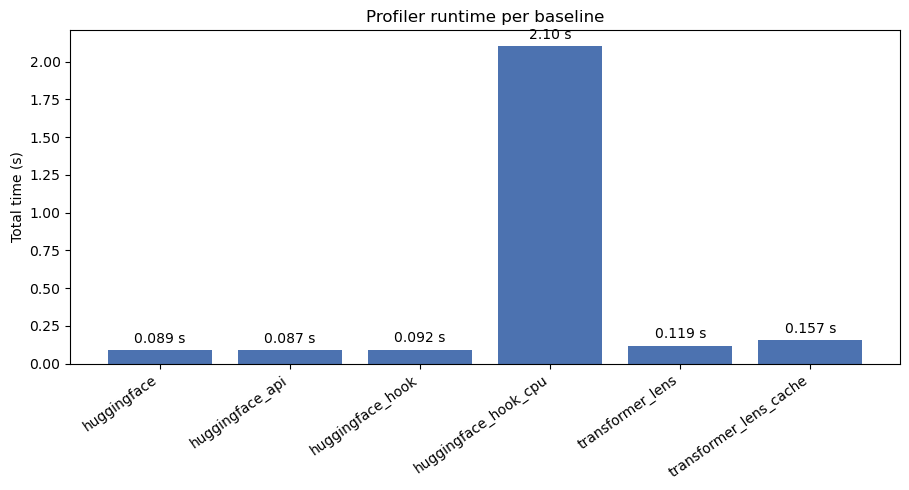

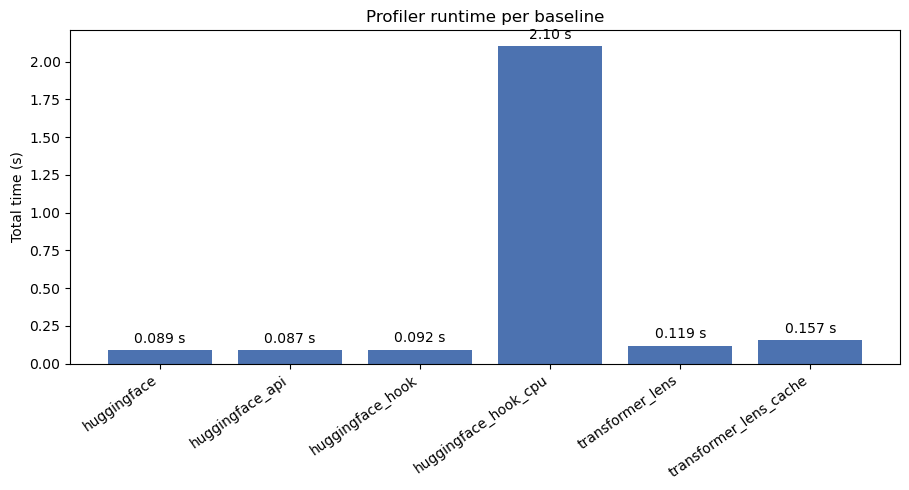

In [ ]:
# Vertical bar chart for total runtime per baseline
fig, ax = plt.subplots(figsize=(1.2 * len(summary_df) + 2, 5))

bars = ax.bar(summary_df["baseline"], summary_df["mean_total_s"], color="#4c72b0")
ax.set_ylabel("Total time (s)")
ax.set_title("Profiler runtime per baseline")
ax.set_xticklabels(summary_df["baseline"], rotation=35, ha="right")

ax.bar_label(bars, labels=[format_seconds(v) for v in summary_df["mean_total_s"]], padding=3)
plt.tight_layout()
fig


/tmp/ipykernel_1664459/1150996947.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(summary_df["baseline"], rotation=35, ha="right")
/tmp/ipykernel_1664459/1150996947.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(summary_df["baseline"], rotation=35, ha="right")
/tmp/ipykernel_1664459/1150996947.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(summary_df["baseline"], rotation=35, ha="right")


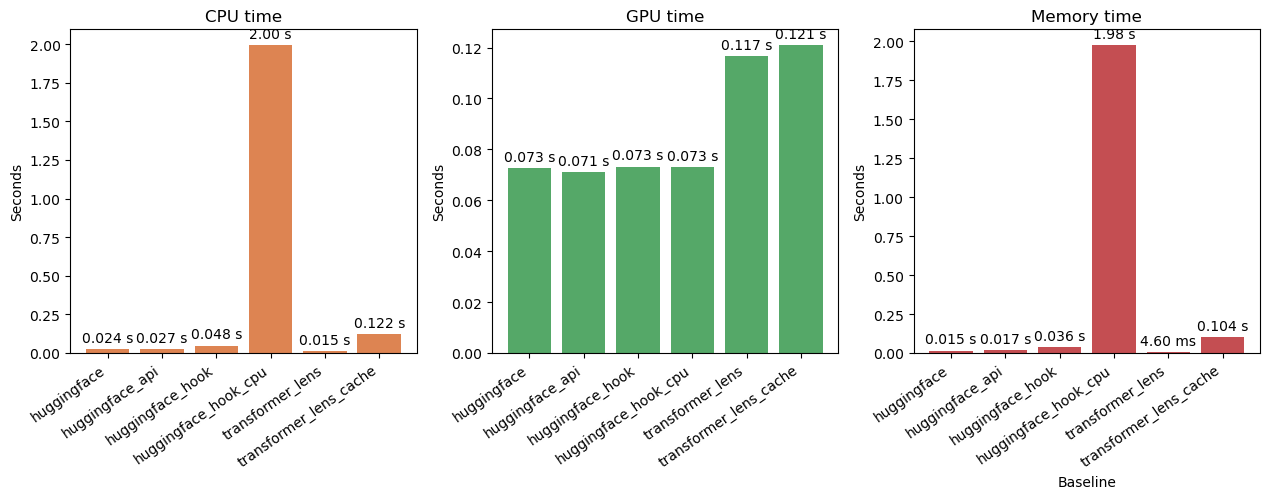

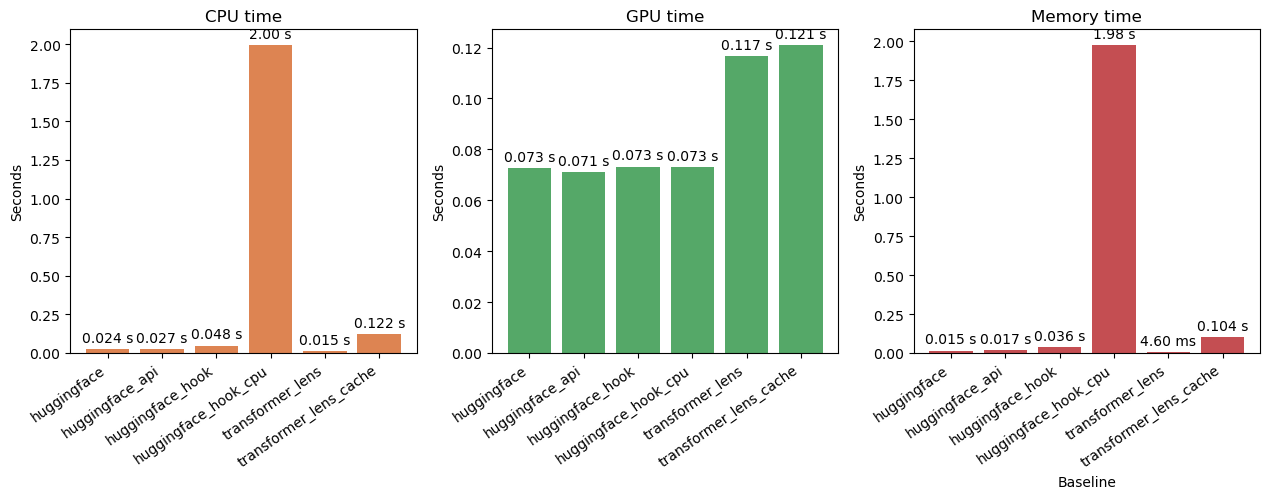

In [ ]:
# CPU / GPU / Memory time comparisons (vertical bars)
metrics = [
    ("mean_cpu_s", "CPU time", "#dd8452"),
    ("mean_gpu_s", "GPU time", "#55a868"),
    ("mean_memory_s", "Memory time", "#c44e52"),
]

fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    sharex=True,
    figsize=(1.8 * len(summary_df) + 2, 1.7 * len(metrics)),
)

if len(metrics) == 1:
    axes = [axes]

for ax, (column, title, color) in zip(axes, metrics):
    bars = ax.bar(summary_df["baseline"], summary_df[column], color=color)
    ax.set_ylabel("Seconds")
    ax.set_title(title)
    ax.bar_label(bars, labels=[format_seconds(v) for v in summary_df[column]], padding=3)
    ax.set_xticklabels(summary_df["baseline"], rotation=35, ha="right")

axes[-1].set_xlabel("Baseline")
plt.tight_layout()
fig


## Detailed operator/runtime breakdown

Aggregate averaged durations by category for the focused baselines.


In [ ]:
breakdown_mean_df = (
    breakdown_df
    .groupby(["baseline", "category"])
    .agg(mean_seconds=("seconds", "mean"))
    .reset_index()
)
focus_breakdown = (
    breakdown_mean_df
    .pivot(index="baseline", columns="category", values="mean_seconds")
    .fillna(0.0)
    .reindex(index=focus_order)
)
focus_breakdown = focus_breakdown.reindex(columns=CATEGORY_ORDER, fill_value=0.0)
focus_breakdown


/tmp/ipykernel_1664459/1140002705.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["baseline", "category"])


category,CUDA memcpy/memset,CUDA malloc/free,CUDA runtime (other),GPU kernel (other),GEMM/Matmul (aten),Attention/Softmax (aten),LayerNorm (aten),Index/Shape (aten),Layout/Permute (aten),Copy/Clone (aten),Tensor Create (aten),Pointwise (aten),aten::other,Annotations,other
baseline,,,,,,,,,,,,,,,
transformer_lens_cache,0.000004,0.103018,0.016149,0.121120,0.066039,0.000346,0.000000,0.032095,0.000386,0.038199,0.101220,0.045375,0.027857,0.460129,0.001626
transformer_lens,0.000004,0.000000,0.099756,0.116532,0.005696,0.000262,0.000000,0.003020,0.000471,0.005815,0.001727,0.004649,0.004316,0.355611,0.001584
huggingface_hook,0.000017,0.035639,0.040758,0.073265,0.010342,0.000241,0.003191,0.009746,0.003944,0.007809,0.012652,0.029847,0.007047,0.275289,0.000375
huggingface_api,0.000017,0.016663,0.055923,0.070952,0.009319,0.000249,0.002729,0.017844,0.000889,0.004301,0.007407,0.012554,0.012847,0.258610,0.001567


/tmp/ipykernel_1664459/1560463280.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(focus_breakdown.index, rotation=20, ha="right")


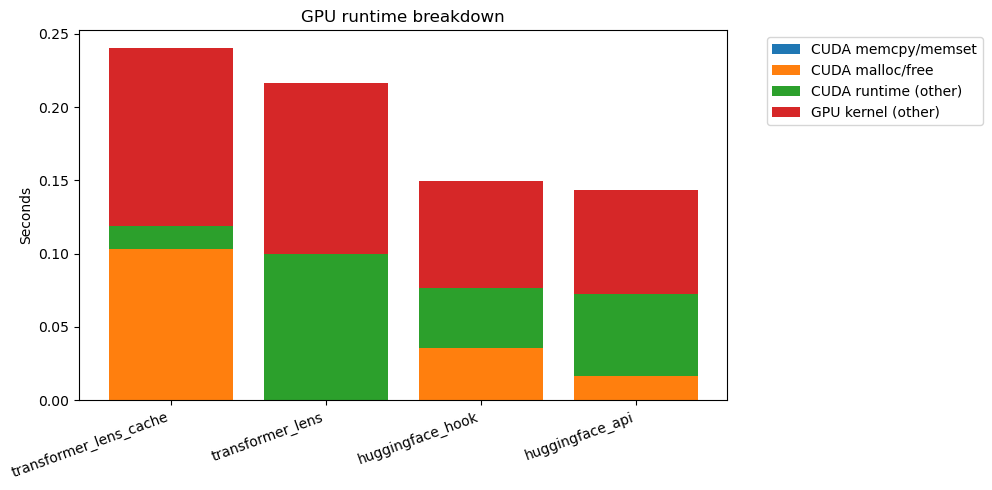

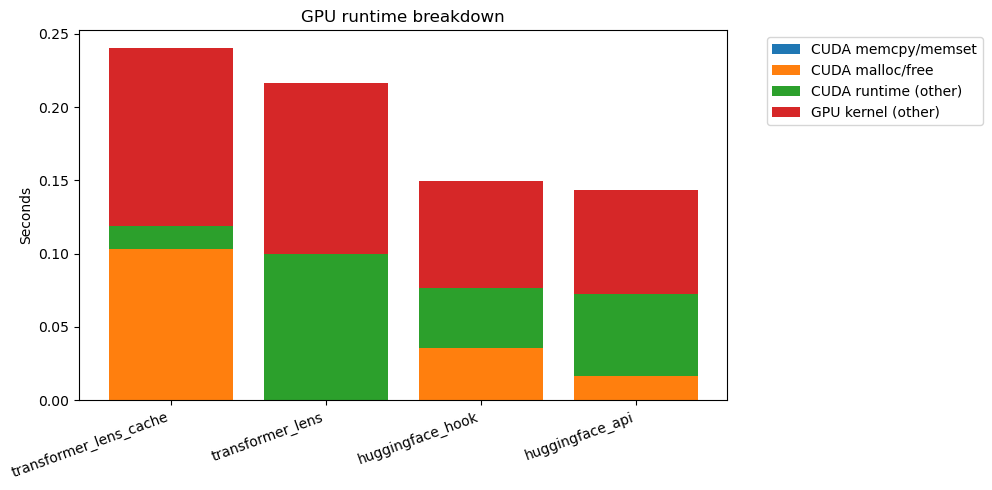

In [ ]:
# Stacked bar chart: GPU-related categories (high-contrast colors)
gpu_categories = [cat for cat in GPU_CATEGORY_ORDER if cat in focus_breakdown.columns]

# Define a high-contrast color palette
high_contrast_colors = [
    "#1f77b4",  # blue
    "#ff7f0e",  # orange
    "#2ca02c",  # green
    "#d62728",  # red
    "#9467bd",  # purple
    "#8c564b",  # brown
    "#e377c2",  # pink
    "#7f7f7f",  # gray
    "#bcbd22",  # yellow-green
    "#17becf",  # cyan
    "#000000",  # black
    "#FFD700",  # gold
    "#00CED1",  # dark turquoise
    "#FF1493",  # deep pink
    "#228B22",  # forest green
    "#FF4500",  # orange red
]

# Assign colors to categories, cycling if needed
category_colors = {cat: high_contrast_colors[i % len(high_contrast_colors)] for i, cat in enumerate(gpu_categories)}

fig, ax = plt.subplots(figsize=(10, 5))
bottom = pd.Series([0.0] * len(focus_breakdown), index=focus_breakdown.index)
for category in gpu_categories:
    values = focus_breakdown[category]
    if values.sum() == 0:
        continue
    bars = ax.bar(
        focus_breakdown.index,
        values,
        bottom=bottom,
        color=category_colors[category],
        label=category
    )
    bottom += values
ax.set_ylabel("Seconds")
ax.set_title("GPU runtime breakdown")
ax.set_xticklabels(focus_breakdown.index, rotation=20, ha="right")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
fig


/tmp/ipykernel_1664459/677368869.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(focus_breakdown.index, rotation=20, ha="right")


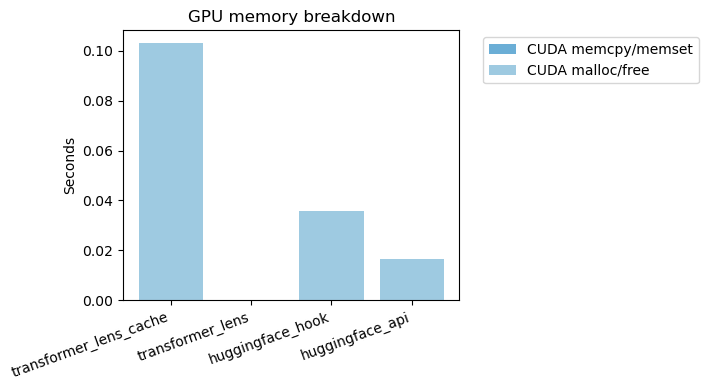

In [ ]:
# Stacked bar chart: Memory-related categories
memory_categories = [cat for cat in gpu_categories if 'mem' in cat.lower() or 'malloc' in cat.lower() or 'free' in cat.lower()]
if memory_categories:
    fig, ax = plt.subplots(figsize=(7, 4))
    bottom = pd.Series([0.0] * len(focus_breakdown), index=focus_breakdown.index)
    for category in memory_categories:
        values = focus_breakdown[category]
        if values.sum() == 0:
            continue
        bars = ax.bar(
            focus_breakdown.index,
            values,
            bottom=bottom,
            color=get_color(category),
            label=category,
        )
        bottom += values
    ax.set_ylabel("Seconds")
    ax.set_title("GPU memory breakdown")
    ax.set_xticklabels(focus_breakdown.index, rotation=20, ha="right")
    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    fig


/tmp/ipykernel_1664459/966767413.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(focus_breakdown.index, rotation=20, ha="right")


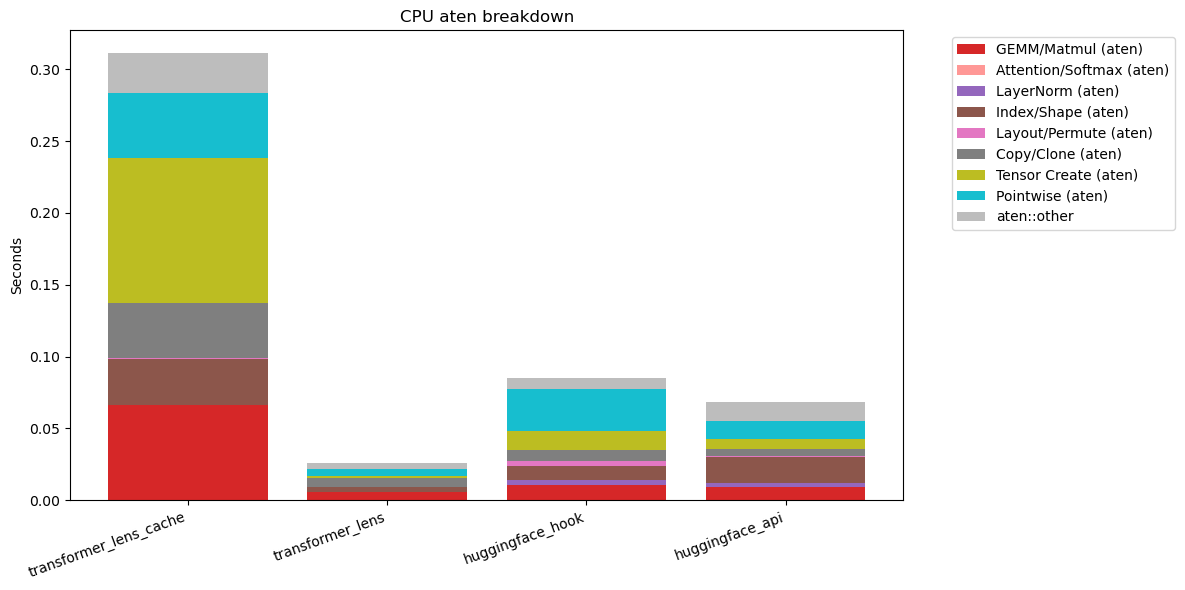

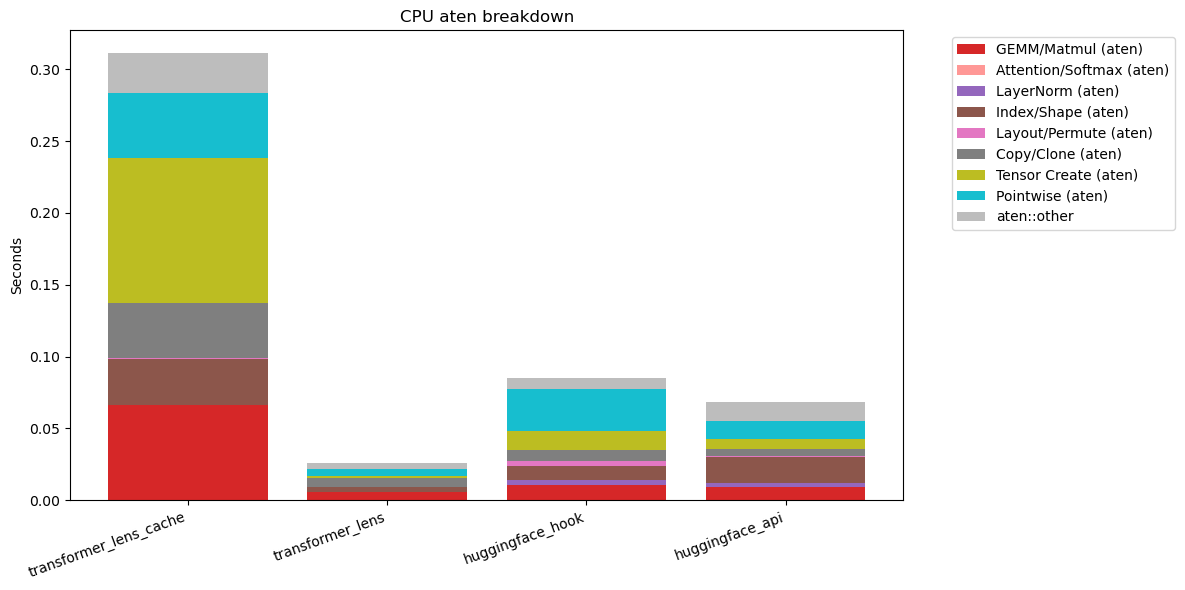

In [ ]:
# Stacked bar chart: CPU aten categories
cpu_categories = [cat for cat in CPU_CATEGORY_ORDER if cat in focus_breakdown.columns]
fig, ax = plt.subplots(figsize=(12, 6))
bottom = pd.Series([0.0] * len(focus_breakdown), index=focus_breakdown.index)
for category in cpu_categories:
    values = focus_breakdown[category]
    if values.sum() == 0:
        continue
    bars = ax.bar(focus_breakdown.index, values, bottom=bottom, color=get_color(category), label=category)
    bottom += values
ax.set_ylabel("Seconds")
ax.set_title("CPU aten breakdown")
ax.set_xticklabels(focus_breakdown.index, rotation=20, ha="right")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
fig
fig
